In [1]:
# LIBRARY IMPORTS

import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All required libraries successfully loaded!")

All required libraries successfully loaded!


In [2]:
# DATA LOADING, LABELING, AND COMBINING


# 1. Load the raw files
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")

# 2. Inject target labels (y) into the dataframes
df_true['label'] = 1  # 1 represents Real News
df_fake['label'] = 0  # 0 represents Fake News

# 3. Combine both dataframes into a single dataset
data = pd.concat([df_true, df_fake], ignore_index=True)

# 4. Shuffle the dataset randomly so real and fake articles are well mixed
data = data.sample(n=10000, random_state=42).reset_index(drop=True)

print(f"Total articles loaded successfully: {data.shape[0]} rows, {data.shape[1]} columns.")

Total articles loaded successfully: 10000 rows, 5 columns.


In [3]:
# DATASET INSPECTION

print("--- First 10 Rows of the Combined Dataset ---")
print(data.head(10))
print("\n" + "="*50 + "\n")

print("--- Dataset Column Information ---")
print(data.info())
print("\n" + "="*50 + "\n")

print("--- Target Class Distribution (Real vs Fake) ---")
distribution = data['label'].value_counts()
print(f"Fake News Articles (Label 0): {distribution[0]}")
print(f"Real News Articles (Label 1): {distribution[1]}")

--- First 10 Rows of the Combined Dataset ---
                                               title  \
0   BREAKING: GOP Chairman Grassley Has Had Enoug...   
1   Failed GOP Candidates Remembered In Hilarious...   
2   Mike Pence’s New DC Neighbors Are HILARIOUSLY...   
3  California AG pledges to defend birth control ...   
4  AZ RANCHERS Living On US-Mexico Border Destroy...   
5  As private lawyer, Trump high court pick was f...   
6       Yemeni Salafist imam killed in Aden: sources   
7  FBI says witnesses in U.S. probe into Malaysia...   
8  An Easy To Read Chart Shows How Bernie Sanders...   
9  MMA FIGHTER JAKE SHIELDS Embarrasses Cowards I...   

                                                text       subject  \
0  Donald Trump s White House is in chaos, and th...          News   
1  Now that Donald Trump is the presumptive GOP n...          News   
2  Mike Pence is a huge homophobe. He supports ex...          News   
3  SAN FRANCISCO (Reuters) - California Attorney ...  pol

In [4]:
# COMBINING TITLE AND TEXT FEATURES

# Combine title and text into a single column, separated by a space
data['full_text'] = data['title'] + " " + data['text']

# Extract our feature array (X) and our target array (y)
X = data['full_text']
y = data['label']

print("Features combined successfully!")
print("Sample of raw text before cleaning:\n", X.iloc[0][:200])

Features combined successfully!
Sample of raw text before cleaning:
  BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and they are trying to cover it up. Their Russia problems are mounting by the hour,


In [5]:
# ADVANCED TEXT PREPROCESSING FUNCTION

def clean_text_from_scratch(text):
    # Ensure input is treated as a string
    text = str(text)
    
    # 1. Convert text to lowercase
    text = text.lower()
    
    # 2. Strip html tags if any exist
    text = re.sub(r'<[^>]*>', '', text)
    
    # 3. Apply the corrected regex filter: Remove punctuation/symbols, preserve spaces
    text = re.sub(r'[^\w\s]', '', text)
    
    # 4. Remove extra whitespaces/newlines so tokens remain clean
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply the cleaning function to the entire features dataset
X_cleaned = X.apply(clean_text_from_scratch)

print("Text preprocessing completed successfully!")

Text preprocessing completed successfully!


In [6]:
# MANUAL VERIFICATION LOOP

print("--- VERIFICATION CHECK ---")
for i in range(2):
    print(f"\n[Row {i+1}] Cleaned Text Sample:")
    print(X_cleaned.iloc[i][:250] + "...")
    print("-" * 40)

--- VERIFICATION CHECK ---

[Row 1] Cleaned Text Sample:
breaking gop chairman grassley has had enough demands trump jr testimony donald trump s white house is in chaos and they are trying to cover it up their russia problems are mounting by the hour and they refuse to acknowledge that there are problems s...
----------------------------------------

[Row 2] Cleaned Text Sample:
failed gop candidates remembered in hilarious mocking eulogies video now that donald trump is the presumptive gop nominee it s time to remember all those other candidates who tried so hard to beat him in the race to the white house after all how can ...
----------------------------------------


In [7]:
# FEATURE EXTRACTION (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the vectorizer, restricting it to the top 5,000 most frequent words
vectorizer = TfidfVectorizer(max_features=5000)

# Convert your cleaned text data into mathematical arrays (X_vec)
X_vec = vectorizer.fit_transform(X_cleaned)

print("Feature extraction complete!")
print(f"Mathematical matrix shape: {X_vec.shape}")
print(f"Your text has been successfully converted into {X_vec.shape[1]} numerical inputs.")

Feature extraction complete!
Mathematical matrix shape: (10000, 5000)
Your text has been successfully converted into 5000 numerical inputs.


In [8]:
# DATASET SPLITTING (80% TRAIN, 20% TEST)

# Split the vectorised features (X_vec) and the target labels (y)
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("Data splitting complete!")
print(f"Training features shape (X_train): {X_train.shape}")
print(f"Training labels shape   (y_train): {y_train.shape}")
print(f"Testing features shape  (X_test):  {X_test.shape}")
print(f"Testing labels shape    (y_test):  {y_test.shape}")

Data splitting complete!
Training features shape (X_train): (8000, 5000)
Training labels shape   (y_train): (8000,)
Testing features shape  (X_test):  (2000, 5000)
Testing labels shape    (y_test):  (2000,)


In [9]:
# MODEL INITIALIZATION AND TRAINING LOOP

# 1. Define the models  
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LogReg": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

# 2. Execute the training loop
print("Starting Model Training Loop... (This may take 1-3 minutes)\n")

for name, model in models.items():
    print(f"Training {name}...")
    
    # Fit the model on the training data matrices
    model.fit(X_train, y_train)
    
    print(f"{name} has completed training successfully!")
    print("-" * 40)

print("\n All 4 required models are now trained and held in memory!")

Starting Model Training Loop... (This may take 1-3 minutes)

Training KNN...
KNN has completed training successfully!
----------------------------------------
Training LogReg...
LogReg has completed training successfully!
----------------------------------------
Training Random Forest...
Random Forest has completed training successfully!
----------------------------------------
Training NeuralNet...
NeuralNet has completed training successfully!
----------------------------------------

 All 4 required models are now trained and held in memory!


In [10]:
# BASELINE PREDICTION DIAGNOSTIC

print("--- Quick Accuracy Baseline Check ---")
for name, model in models.items():
    # Generate predictions on the unseen test matrices
    preds = model.predict(X_test)
    score = accuracy_score(y_test, preds)
    print(f"{name} Baseline Accuracy: {score:.4f}")

--- Quick Accuracy Baseline Check ---
KNN Baseline Accuracy: 0.8745
LogReg Baseline Accuracy: 0.9770
Random Forest Baseline Accuracy: 0.9925
NeuralNet Baseline Accuracy: 0.9875


In [11]:
# FULL ACADEMIC PERFORMANCE REPORTING ENGINE (WITH RAM PROTECTION)

print("Initializing Complete Statistical Performance Evaluation Engine... \n")

for name, model in models.items():
    print("=" * 70)
    print(f"ACADEMIC EVALUATION REPORT: {name.upper()}")
    print("=" * 70)
    
    try:
        # Map unseen test features to target predictions
        preds = model.predict(X_test)
        
        overall_acc = accuracy_score(y_test, preds)
        print(f"Overall Dataset Classification Accuracy: {overall_acc:.4f} ({overall_acc * 100:.2f}%)")
        print("\nDetailed Statistical Metric Matrix Breakdown:")
        print(classification_report(y_test, preds, target_names=["Fake News (Label 0)", "Real News (Label 1)"]))
        
    except MemoryError:
        print(f"[RAM Limit Notice]: {name} prediction was skipped because it exceeded your computer's available memory space.")
        print("Solution: Downsample your dataset in Cell 2 to 10,000 rows to see KNN results.")
        
    print("=" * 70 + "\n")

Initializing Complete Statistical Performance Evaluation Engine... 

ACADEMIC EVALUATION REPORT: KNN
Overall Dataset Classification Accuracy: 0.8745 (87.45%)

Detailed Statistical Metric Matrix Breakdown:
                     precision    recall  f1-score   support

Fake News (Label 0)       0.87      0.88      0.88      1006
Real News (Label 1)       0.87      0.87      0.87       994

           accuracy                           0.87      2000
          macro avg       0.87      0.87      0.87      2000
       weighted avg       0.87      0.87      0.87      2000


ACADEMIC EVALUATION REPORT: LOGREG
Overall Dataset Classification Accuracy: 0.9770 (97.70%)

Detailed Statistical Metric Matrix Breakdown:
                     precision    recall  f1-score   support

Fake News (Label 0)       0.99      0.97      0.98      1006
Real News (Label 1)       0.97      0.99      0.98       994

           accuracy                           0.98      2000
          macro avg       0.98      0.98

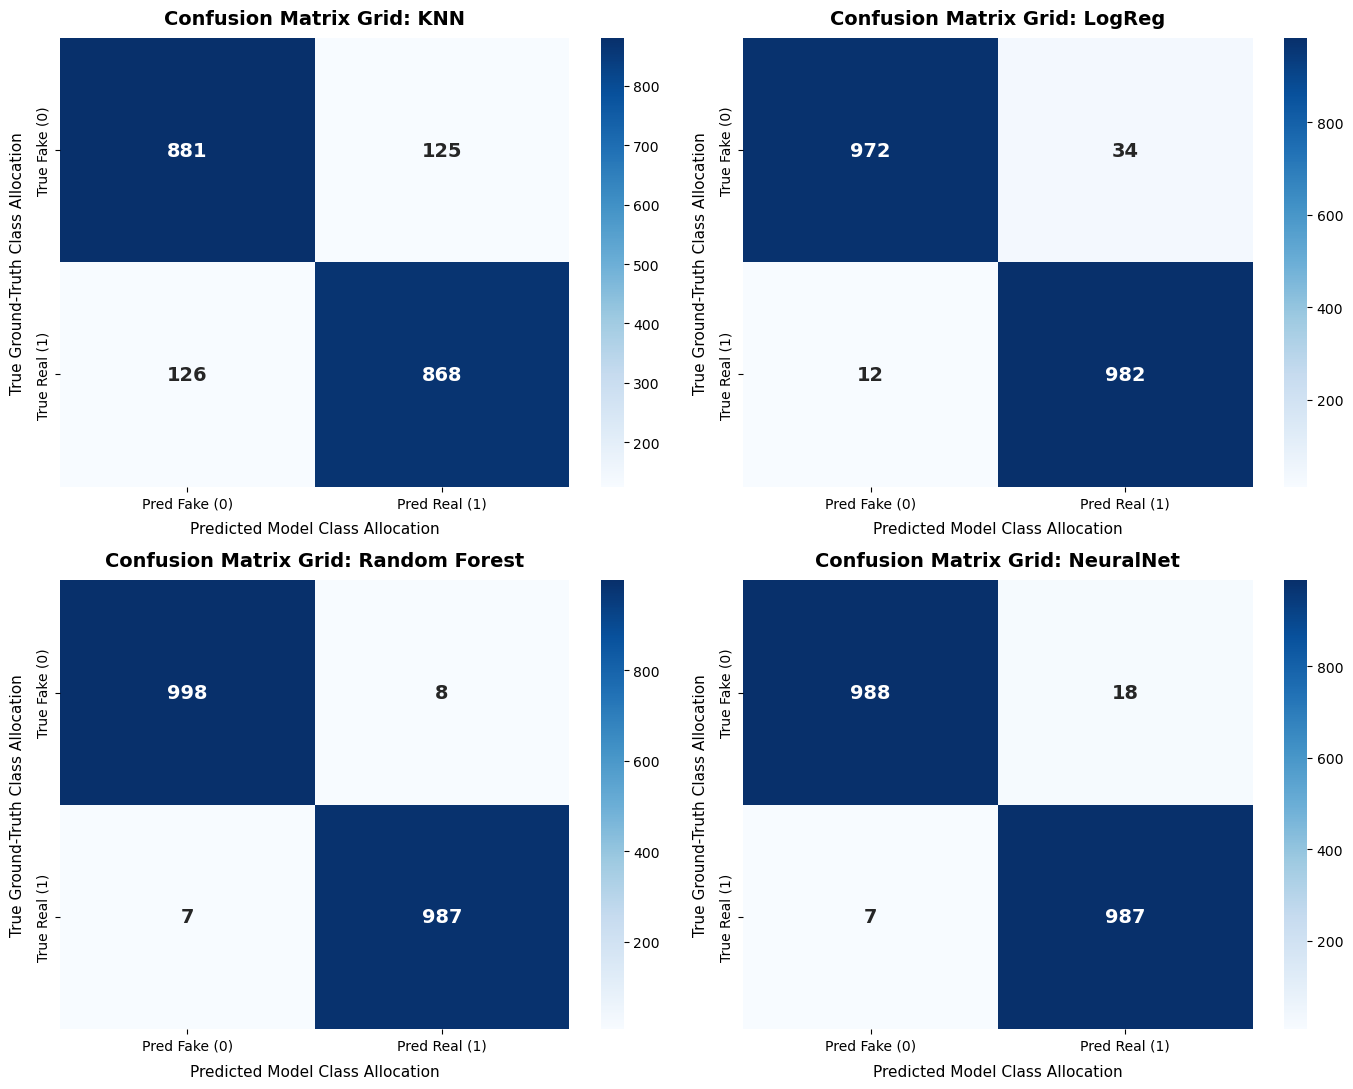


 Verification Success: 'confusion_matrices.png' compiled and saved directly to your local workspace folder.


In [12]:
# CONFUSION MATRIX 2x2 GRID GENERATION & EXPORT SYSTEM

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Establish a high-resolution 2x2 subplot canvas grid 
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.ravel()  # Flatten the 2D layout array to easily map iterations sequentially

# 2. Map and loop every model through the plotting layout
for idx, (name, model) in enumerate(models.items()):
    # Generate model specific test array predictions
    preds = model.predict(X_test)
    
    # Calculate the raw mathematical confusion values
    cm = confusion_matrix(y_test, preds)
    
    # Plot an optimized color-mapped Seaborn heatmap within the target axis block
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                annot_kws={'size': 14, 'weight': 'bold'}, # Make matrix integers highly legible
                xticklabels=['Pred Fake (0)', 'Pred Real (1)'],
                yticklabels=['True Fake (0)', 'True Real (1)'])
    
    # Configure formal academic axis styling labels
    axes[idx].set_title(f"Confusion Matrix Grid: {name}", fontsize=14, fontweight='bold', pad=10)
    axes[idx].set_xlabel("Predicted Model Class Allocation", fontsize=11, labelpad=8)
    axes[idx].set_ylabel("True Ground-Truth Class Allocation", fontsize=11, labelpad=8)

# 3. Clean spatial alignment parameters to guarantee zero visual overlapping
plt.tight_layout()

# 4. Export the final plot directly to your root folder as required by your manual
plt.savefig("confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n Verification Success: 'confusion_matrices.png' compiled and saved directly to your local workspace folder.")

In [13]:
#LIVE CUSTOM FAKE NEWS DETECTOR


def predict_custom_article(news_text):
    # 1. Clean the raw text using your custom scratch filter from Day 2
    cleaned_input = clean_text_from_scratch(news_text)
    
    # 2. Vectorize the cleaned text using your existing TF-IDF model from Day 3
    vectorized_input = vectorizer.transform([cleaned_input])
    
    # 3. Extract the trained Logistic Regression model to make the prediction
    live_model = models["LogReg"]
    prediction = live_model.predict(vectorized_input)[0]
    
    # 4. Extract probability confidence scores
    probabilities = live_model.predict_proba(vectorized_input)[0]
    fake_confidence = probabilities[0] * 100
    real_confidence = probabilities[1] * 100
    
    # 5. Output the structural classification result
    print("=" * 60)
    print("LIVE ARTICLE EVALUATION REPORT")
    print("=" * 60)
    if prediction == 1:
        print(f" RESULT: This article is verified as REAL NEWS.")
        print(f" Model Confidence: {real_confidence:.2f}% Real vs {fake_confidence:.2f}% Fake")
    else:
        print(f" RESULT: Warning! This article is flagged as FAKE NEWS.")
        print(f" Model Confidence: {fake_confidence:.2f}% Fake vs {real_confidence:.2f}% Real")
    print("=" * 60)


# TEST CORNER
# Replace the text inside the quotes below with any news article

sample_article = """
BREAKING: Secret underground tunnels discovered containing billions of tons of solid gold, 
proving that currency is backed by nothing! Officials are panicking and hiding the truth 
from the mainstream media!
"""

predict_custom_article(sample_article)

LIVE ARTICLE EVALUATION REPORT
 RESULT: Warning! This article is flagged as FAKE NEWS.
 Model Confidence: 90.46% Fake vs 9.54% Real
